In [25]:
import os
import sys
import subprocess
import importlib
import zipfile
import warnings
warnings.filterwarnings("ignore")

# 1. Required pip libraries (Torch is excluded — installed via conda)
required_libraries = [
    "opencv-python-headless",
    "segmentation-models-pytorch",
    "albumentations",
    "pandas",
    "matplotlib",
    "seaborn",
    "Pillow",
    "scikit-learn"
]

def install_missing_packages(libraries):
    for lib in libraries:
        try:
            importlib.import_module(lib.split("==")[0])
        except ImportError:
            print(f"Installing missing package: {lib}")
            subprocess.check_call([sys.executable, "-m", "pip", "install", lib])

install_missing_packages(required_libraries)


# 2. Imports (after installation)
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from collections import Counter

# PyTorch (already installed in conda env)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


# 3. Check Environment (GPU / CUDA)
print("\n=== Environment Info ===")
print("Python:", sys.version.split()[0])
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("⚠ Running on CPU — GPU not detected")

Installing missing package: opencv-python-headless


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/igraph-0.11.8-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


Installing missing package: segmentation-models-pytorch


...

Installing missing package: scikit-learn


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/igraph-0.11.8-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



=== Environment Info ===
Python: 3.12.3
PyTorch version: 2.3.0+cu121
CUDA available: True
GPU detected: NVIDIA H100 80GB HBM3 MIG 3g.40gb



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


In [26]:
#Exploratory Data Analysis (EDA)
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError
import random
import cv2


# Universal EDA Function WITH Saving of Plots + Image-Mask-Overlay
def run_eda(dataset_folder, output_folder):

    os.makedirs(output_folder, exist_ok=True)

    print(f"Running EDA on: {dataset_folder}")
    print(f"Saving results to: {output_folder}")
    print("="*80)

    all_files = sorted(os.listdir(dataset_folder))

    # Find sat images + masks
    image_names = [
        f for f in all_files
        if "_sat" in f.lower() and f.lower().endswith((".jpg", ".png"))
    ]

    mask_names = [
        f for f in all_files
        if "_mask" in f.lower() and f.lower().endswith((".jpg", ".png"))
    ]

    print(f"Total satellite images: {len(image_names)}")
    print(f"Total masks: {len(mask_names)}")

    if not image_names:
        print("No satellite images found in:", dataset_folder)
        return

    # 1. Sample Visualization + Save Images

    def get_base_id(fname):
        return fname.split("_sat")[0]

    i = random.randint(0, len(image_names) - 1)
    img_file = image_names[i]
    base_id = get_base_id(img_file)

    mask_png = f"{base_id}_mask.png"
    mask_jpg = f"{base_id}_mask.jpg"
    mask_file = mask_png if mask_png in mask_names else mask_jpg

    img_path = os.path.join(dataset_folder, img_file)
    mask_path = os.path.join(dataset_folder, mask_file)

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path).convert("L"))

    # Save sample satellite image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Sample Satellite Image")
    plt.show()
    plt.savefig(os.path.join(output_folder, "sample_image.png"), bbox_inches='tight')
    plt.close()

    # Save mask
    plt.imshow(mask, cmap='gray')
    plt.axis("off")
    plt.title("Sample Mask")
    plt.show()
    plt.savefig(os.path.join(output_folder, "sample_mask.png"), bbox_inches='tight')
    plt.close()

    # Overlay Image
    overlay = np.zeros_like(img)
    overlay[..., 1] = mask
    blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    plt.imshow(blended)
    plt.axis("off")
    plt.title("Overlay: Satellite + Road Mask")
    plt.show()
    plt.savefig(os.path.join(output_folder, "sample_overlay.png"), bbox_inches='tight')
    plt.close()


    # 2. Mask Coverage Analysis + Save
    print("\nMask coverage analysis...")

    mask_coverage = []
    for mask_name in tqdm(mask_names):
        m = np.array(Image.open(os.path.join(dataset_folder, mask_name)).convert("L"))
        mask_coverage.append((m > 0).mean())

    plt.hist(mask_coverage, bins=30, color='steelblue', edgecolor='black')
    plt.title("Mask Coverage Distribution")
    plt.xlabel("Road Pixel %")
    plt.ylabel("Count")
    plt.show()
    plt.savefig(os.path.join(output_folder, "mask_coverage_hist.png"), bbox_inches='tight')
    plt.close()


    # 3. Brightness Analysis + Save
    print("\nBrightness analysis...")

    brightness_values = []
    sample_images = random.sample(image_names, min(100, len(image_names)))

    for name in tqdm(sample_images):
        img = cv2.imread(os.path.join(dataset_folder, name))
        brightness_values.append(img.mean())

    plt.hist(brightness_values, bins=30, color='orange', edgecolor='black')
    plt.title("Brightness Distribution")
    plt.xlabel("Average Pixel")
    plt.ylabel("Count")
    plt.show()
    plt.savefig(os.path.join(output_folder, "brightness_hist.png"), bbox_inches='tight')
    plt.close()


    # Summary
    print("\nSUMMARY")
    print(f"Images: {len(image_names)}")
    print(f"Masks : {len(mask_names)}")
    print(f"Mean Coverage: {np.mean(mask_coverage):.4f}")
    print(f"Brightness Range: {min(brightness_values):.2f} – {max(brightness_values):.2f}")

Running EDA on: /workspace/ML Main Large/train
Saving results to: /workspace/ML Main Large/EDA_Results/train
Total satellite images: 14688
Total masks: 14688


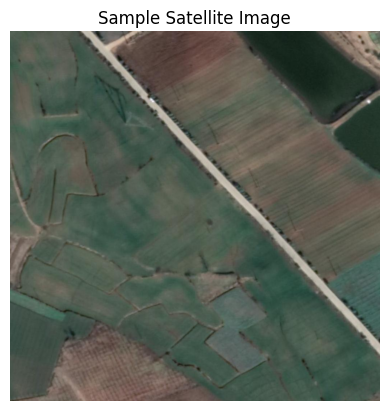

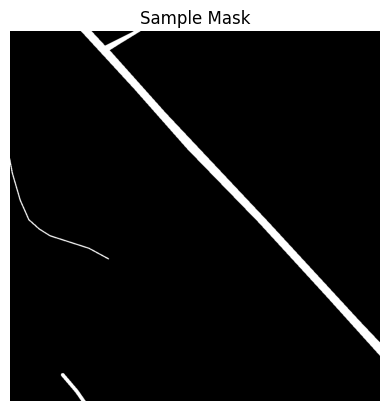

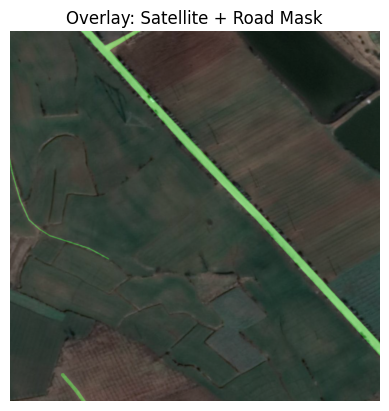


Mask coverage analysis...



00%|██████████| 14688/14688 [00:35<00:00, 413.66it/s]

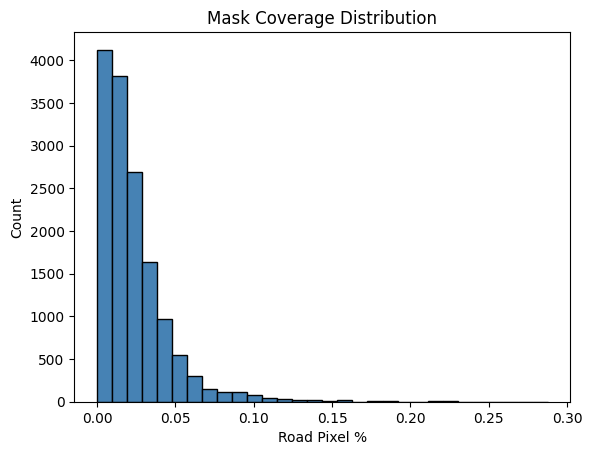


Brightness analysis...



00%|██████████| 100/100 [00:00<00:00, 221.81it/s]

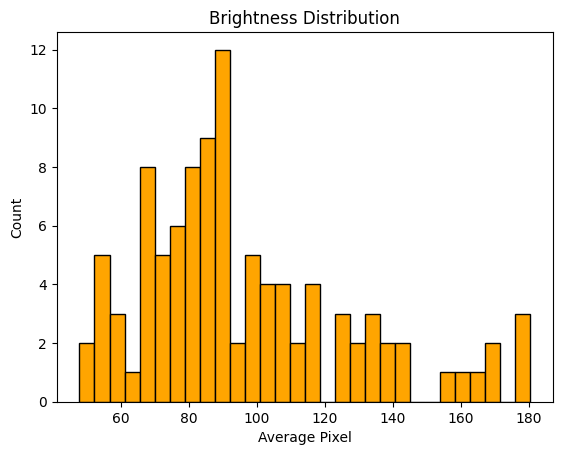


SUMMARY
Images: 14688
Masks : 14688
Mean Coverage: 0.0225
Brightness Range: 47.67 – 180.55
Running EDA on: /workspace/ML Main Large/test
Saving results to: /workspace/ML Main Large/EDA_Results/test
Total satellite images: 13082
Total masks: 13082


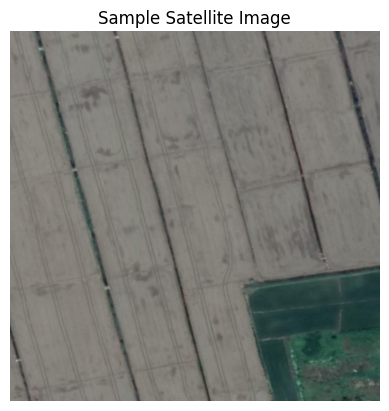

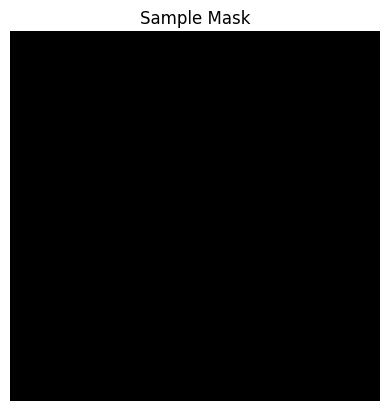

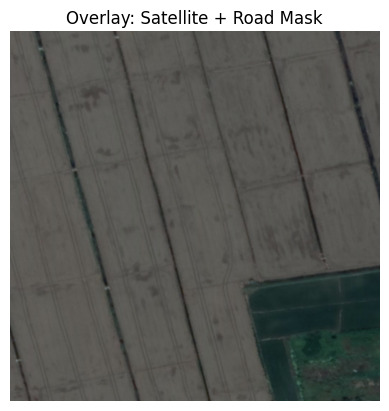


Mask coverage analysis...



00%|██████████| 13082/13082 [00:31<00:00, 411.33it/s]

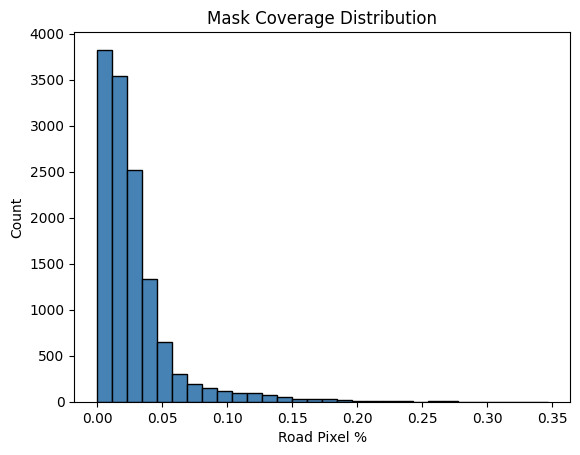


Brightness analysis...



00%|██████████| 100/100 [00:00<00:00, 231.11it/s]

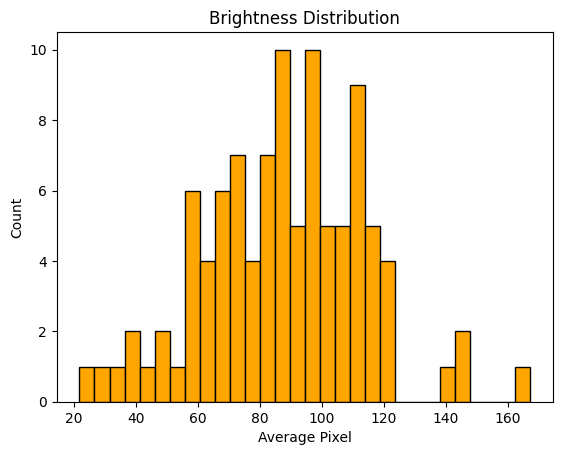


SUMMARY
Images: 13082
Masks : 13082
Mean Coverage: 0.0274
Brightness Range: 21.76 – 167.22


In [27]:
root_dir = "/workspace/ML Main Large"

train_path = os.path.join(root_dir, "train")
test_path = os.path.join(root_dir, "test")

train_output = os.path.join(root_dir, "EDA_Results", "train")
test_output  = os.path.join(root_dir, "EDA_Results", "test")

run_eda(train_path, train_output)
run_eda(test_path, test_output)


Processing train set – 14688 images



00%|██████████| 14688/14688 [02:01<00:00, 121.10it/s]

Finished train split: saved 14688 images.

Processing test set – 13082 images



00%|██████████| 13082/13082 [01:08<00:00, 191.68it/s]

Finished test split: saved 13082 images.
All splits processed successfully!


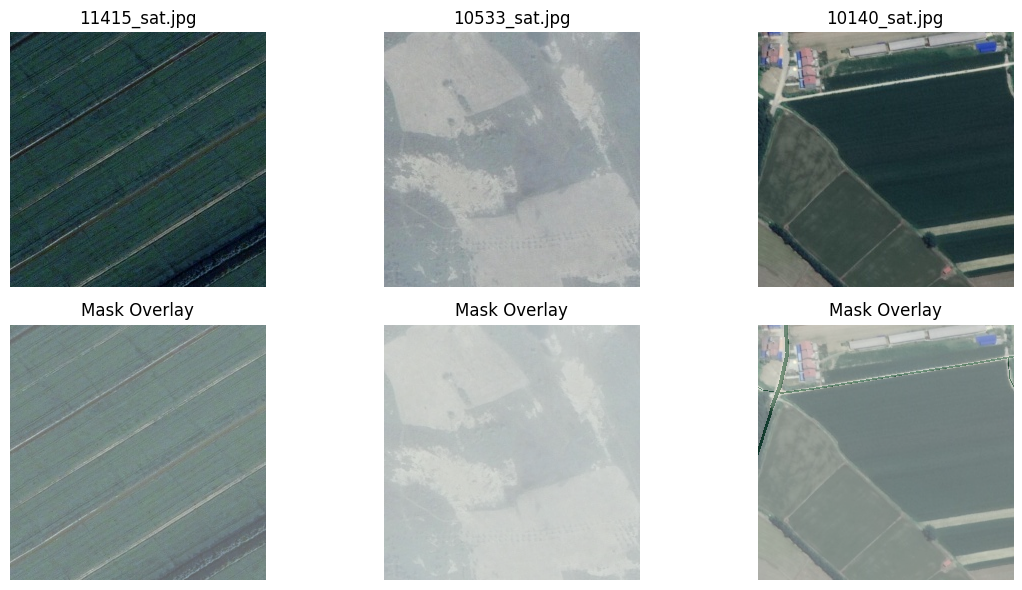

In [28]:
# STEP 3 – DATA PREPROCESSING (Resize + Mask Normalization)

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
# CONFIGURATION
# CONFIGURATION
RAW_DATA_DIR = r"/workspace/ML Main Large"     # dataset root
PROCESSED_DIR = r"/workspace/ML Main Large/Processed data"
TARGET_SIZE = (256, 256)

splits = ["train", "test"]
subdirs = ["images", "masks"]


# CREATE PROCESSED FOLDER STRUCTURE
for split in splits:
    for sub in subdirs:
        os.makedirs(os.path.join(PROCESSED_DIR, split, sub), exist_ok=True)


# Helper: get mask filename
def get_mask_name(img_name):
    base = img_name.split("_sat")[0]
    for ext in [".png", ".jpg", ".jpeg"]:
        candidate = f"{base}_mask{ext}"
        return candidate  # mask always .png in your dataset


# PROCESSING FUNCTION
def preprocess_and_save(split):

    img_dir = os.path.join(RAW_DATA_DIR, split)
    out_img_dir = os.path.join(PROCESSED_DIR, split, "images")
    out_mask_dir = os.path.join(PROCESSED_DIR, split, "masks")

    img_files = [f for f in os.listdir(img_dir) if "_sat" in f]

    print(f"\nProcessing {split} set – {len(img_files)} images")

    count = 0

    for img_name in tqdm(img_files):
        img_path = os.path.join(img_dir, img_name)

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Resize image
        img_resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
        cv2.imwrite(os.path.join(out_img_dir, img_name), img_resized)

        # TRAIN SPLIT → HAS MASKS
        if split == "train":
            base = img_name.split("_sat")[0]
            mask_name = f"{base}_mask.png"
            mask_path = os.path.join(img_dir, mask_name)

            if not os.path.exists(mask_path):
                print(f"⚠ Train mask missing: {mask_name}")
                continue

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue

            mask_resized = cv2.resize(mask, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
            mask_bin = (mask_resized > 127).astype(np.uint8) * 255
            cv2.imwrite(os.path.join(out_mask_dir, mask_name), mask_bin)

        count += 1

    print(f"Finished {split} split: saved {count} images.")

# RUN PREPROCESSING
for split in splits:
    preprocess_and_save(split)

print("All splits processed successfully!")

# VERIFICATION SECTION
def verify_processed_samples():

    sample_split = "train"
    img_dir = os.path.join(PROCESSED_DIR, sample_split, "images")
    mask_dir = os.path.join(PROCESSED_DIR, sample_split, "masks")

    img_list = os.listdir(img_dir)
    if not img_list:
        print("No processed files to verify.")
        return

    samples = random.sample(img_list, min(3, len(img_list)))

    plt.figure(figsize=(12, 6))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(img_dir, img_name)

        base = img_name.split("_sat")[0]
        mask_name = f"{base}_mask.png"
        mask_path = os.path.join(mask_dir, mask_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")

        plt.subplot(2, 3, i + 4)
        plt.imshow(img)
        plt.imshow(mask, cmap='Greens', alpha=0.4)
        plt.title("Mask Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Run verification
verify_processed_samples()